In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# PageRank Algorithm: Mathematical Foundations and Python Implementation

Final Project

This project explores the PageRank algorithm, one of the most influential algorithms used for ranking web pages.

We will:

- explain the mathematical theory behind PageRank
- implement the algorithm in Python
- test it on example graphs
- analyze the results

The goal is to understand how graph theory, linear algebra and probability combine to solve ranking problems in networks.


# 1. Problem Formulation

The rapid growth of the internet created a problem: how can we rank millions of web pages based on importance?

A naive solution would be to simply count the number of links pointing to a page. However, not all links are equal. A link from an important page should count more than a link from an unimportant one.

The PageRank algorithm solves this problem using graph theory and probability.

Web pages are represented as nodes in a directed graph, and hyperlinks are represented as edges between nodes.

The objective of the algorithm is to assign a numerical score to each node representing its relative importance in the network.

# 2. Mathematical Background

PageRank is based on the concept of a **random surfer model**.

Imagine a user randomly clicking links on the web. The probability of landing on a page defines its importance.

Mathematically, PageRank can be defined using the formula:

PR(i) = (1 - d)/N + d * Σ (PR(j) / L(j))

Where:

PR(i) – PageRank of page i  
d – damping factor (usually 0.85)  
N – total number of pages  
PR(j) – PageRank of page j linking to page i  
L(j) – number of outgoing links from page j  

This formula is repeatedly applied until the values converge.

The PageRank vector can also be interpreted as the dominant eigenvector of a stochastic matrix.

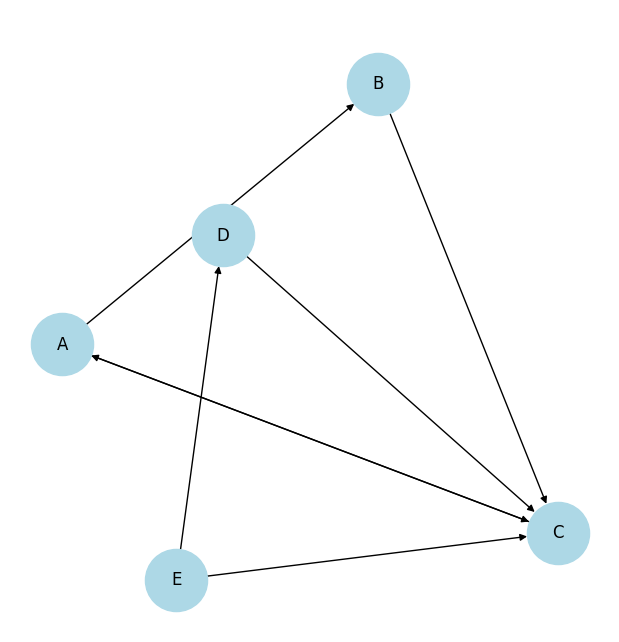

In [9]:
G = nx.DiGraph()

edges = [
    ("A","B"),
    ("A","C"),
    ("B","C"),
    ("C","A"),
    ("D","C"),
    ("E","C"),
    ("E","D")
]

G.add_edges_from(edges)

plt.figure(figsize=(6,6))
nx.draw(G, with_labels=True, node_color="lightblue", node_size=2000)
plt.title("Example Web Graph")
plt.show()

This graph shows the structure of the web pages in the corpus. Each node represents a page and each arrow represents a link from one page to another. This directed graph is used by the PageRank algorithm to calculate the importance of each page based on the incoming links it receives.

# 3. Implementing the PageRank Algorithm

We now implement PageRank from scratch using the mathematical formula.

The algorithm works iteratively until the values stabilize.

In [10]:
def pagerank(graph, d=0.85, max_iter=100, tol=1e-6):

    nodes = list(graph.nodes())
    N = len(nodes)

    rank = {node: 1/N for node in nodes}

    for _ in range(max_iter):

        new_rank = {}

        for node in nodes:

            total = 0

            for neighbor in graph.predecessors(node):
                total += rank[neighbor] / graph.out_degree(neighbor)

            new_rank[node] = (1-d)/N + d*total

        diff = sum(abs(new_rank[n] - rank[n]) for n in nodes)

        rank = new_rank

        if diff < tol:
            break

    return rank

In [11]:
ranks = pagerank(G)

ranks

{'A': 0.3584680536176169,
 'B': 0.18234881320052151,
 'C': 0.3864331331818619,
 'D': 0.04275000000000001,
 'E': 0.030000000000000006}

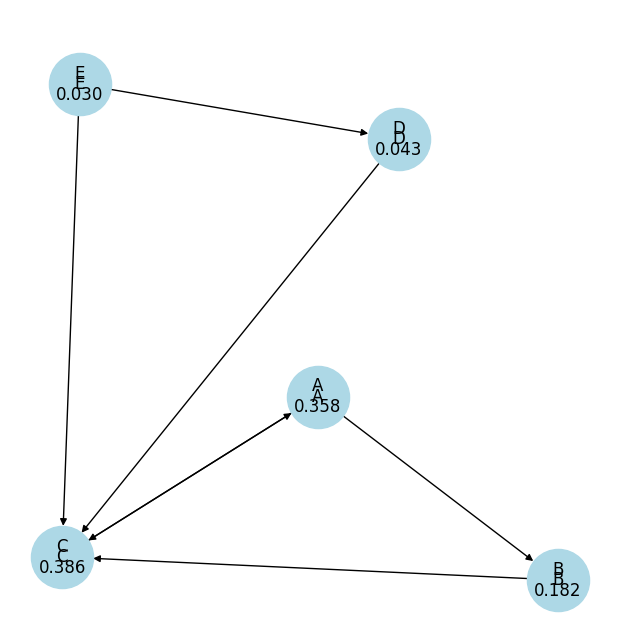

In [12]:
plt.figure(figsize=(6,6))

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")

labels = {node: f"{node}\n{rank:.3f}" for node, rank in ranks.items()}

nx.draw_networkx_labels(G, pos, labels)

plt.title("PageRank Scores")
plt.show()

## Results Analysis

From the computed PageRank values we observe that node C receives the highest rank.

This occurs because several nodes link to C:

B → C
D → C
E → C

Since PageRank distributes importance through incoming links, node C accumulates a higher score.

Node A also receives a relatively high rank because it receives a link from C, which itself is highly ranked.

Nodes D and E have the lowest scores because few pages link to them.

This demonstrates the fundamental idea behind the PageRank algorithm: pages become important when other important pages link to them.

# 4. Comparison with NetworkX Implementation

To verify the correctness of our implementation we compare the results with the implementation from the NetworkX library.

In [13]:
nx_ranks = nx.pagerank(G)

nx_ranks

{'A': 0.3584672782781243,
 'B': 0.18234895015634672,
 'C': 0.3864337715655293,
 'D': 0.04275000000000001,
 'E': 0.030000000000000006}

## 5. Computational Complexity

The PageRank algorithm works iteratively until convergence.

Let:

N = number of nodes
E = number of edges
k = number of iterations until convergence

During each iteration the algorithm processes all nodes and their incoming links.

Therefore the time complexity of the algorithm is approximately:

O(k * E)

The space complexity is:

O(N)

because we only store the rank values for each node and the graph structure.

In practice PageRank can scale to extremely large graphs when optimized implementations are used.

# 6. Conclusion

In this project we explored the PageRank algorithm from both a mathematical and practical perspective.

We modeled the web as a directed graph and implemented the PageRank algorithm from scratch using Python.

The results were compared with the NetworkX implementation, demonstrating that our implementation produces consistent rankings.

This project illustrates how linear algebra, probability and graph theory can be combined to solve real-world ranking problems.

Future work could include:

- testing PageRank on larger datasets
- analyzing convergence speed
- experimenting with different damping factors
- implementing optimized versions of the algorithm
- Future work could include:
testing PageRank on larger datasets
analyzing convergence speed
experimenting with different damping factors
implementing optimized versions of the algorithm

## 7. References

1. Page, L., Brin, S. (1998). The PageRank Citation Ranking: Bringing Order to the Web.
2. NetworkX Documentation – PageRank Algorithm.
3. Introduction to Algorithms – Cormen, Leiserson, Rivest, Stein.
4. Wikipedia – PageRank Algorithm.